# Continuous Bag of Words (CBOW): Learning Word Embeddings from Context

### A teaching notebook on the Word2Vec CBOW architecture, its mathematics, and a from-scratch implementation

Before deep contextual language models existed, a much simpler idea reshaped natural language
processing: represent every word as a dense vector learned purely from how it co-occurs with other
words in raw, unlabelled text. This notebook builds that idea — the **Continuous Bag of Words
(CBOW)** architecture from Mikolov et al.'s 2013 Word2Vec framework — from the ground up:
intuition, mathematics, architecture, and a working numpy implementation trained on a small toy
corpus, ending with a 2D visualisation showing semantically related words clustering together.

**Roadmap**

1. Why one-hot, Bag-of-Words, and TF-IDF representations are insufficient
2. The distributional hypothesis and the Word2Vec framework
3. CBOW's core idea and the sliding-window mechanism
4. Mathematical formulation: context averaging, softmax, the training objective
5. Full neural architecture, layer by layer
6. The softmax bottleneck and optimisation techniques (hierarchical softmax, negative sampling)
7. A from-scratch CBOW implementation trained on a toy corpus, with embeddings visualised in 2D
8. CBOW vs. Skip-gram, advantages, limitations, and modern descendants


## 1. Why Earlier Representations Fall Short

Machine learning models operate on numbers, so words must somehow become vectors. Three classic
approaches all share the same fundamental weakness — they cannot capture *meaning*.

- **One-hot encoding.** Each word becomes a vector of length $V$ (vocabulary size) with a single
  $1$. Every pair of words is equally distant: "king" and "queen" are exactly as dissimilar as
  "king" and "table". The vectors also become enormous as vocabulary grows.
- **Bag-of-Words (BoW).** Counts word occurrences but discards order and contextual relationships
  between words entirely.
- **TF-IDF.** Re-weights word counts by their importance to a document, but still has no notion
  of which words are semantically similar to one another.

These limitations motivated *neural* word embeddings. Word2Vec (Mikolov et al., 2013) learns
dense, low-dimensional vectors in which semantically similar words end up close together in
vector space — and it does so without any manual labelling, purely by predicting words from their
surrounding context.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

np.random.seed(42)
COLORS = ["#2563eb", "#dc2626", "#16a34a", "#d97706", "#7c3aed", "#0891b2", "#db2777"]


## 2. The Distributional Hypothesis and the Word2Vec Framework

> "You shall know a word by the company it keeps." — J. R. Firth (1957)

This single sentence is the conceptual seed of every modern word-embedding model: words that
tend to appear in similar contexts tend to have similar meanings. CBOW operationalises this idea
directly as a *prediction task*.

Word2Vec contains two sibling architectures built on the same idea:

- **CBOW (Continuous Bag of Words)** — predict the centre word from its surrounding context words (this notebook).
- **Skip-gram** — predict the surrounding context words from the centre word.

Both learn an embedding matrix $W \in \mathbb{R}^{V\times d}$, where $V$ is vocabulary size and $d$
is the embedding dimension (commonly 100–300). After training, each row of $W$ *is* the learned
vector for the corresponding word.


## 3. CBOW's Core Idea

**Objective.** Given the words inside a sliding window around a target word, predict that target
(centre) word. CBOW treats all context words equally — it is a "bag" because their order is
discarded; the context word vectors are simply averaged together.

**Worked example.** In the sentence *"The quick brown fox jumps over the lazy dog"*, with centre
word *"fox"* and window size $m=2$, the context is `["quick", "brown", "jumps", "over"]`. CBOW's
task is to predict *"fox"* from the average of those four context word vectors.

The diagram below visualises the sliding window mechanism: the orange box is the target word to
predict, the blue boxes are the context words used as input, and the grey boxes fall outside the
window and are ignored for this particular training step.


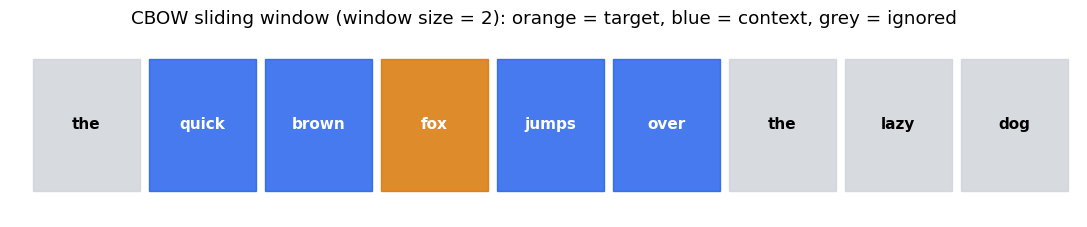

In [2]:
sentence = "the quick brown fox jumps over the lazy dog".split()
center_idx = sentence.index("fox")
window = 2

fig, ax = plt.subplots(figsize=(11, 2.4))
for i, w in enumerate(sentence):
    if i == center_idx:
        color = "#d97706"
    elif abs(i - center_idx) <= window:
        color = "#2563eb"
    else:
        color = "#d1d5db"
    ax.add_patch(plt.Rectangle((i, 0), 0.92, 1, color=color, alpha=0.85))
    ax.text(i + 0.46, 0.5, w, ha="center", va="center", fontsize=11,
             color="white" if color != "#d1d5db" else "black", weight="bold")

ax.set_xlim(-0.2, len(sentence))
ax.set_ylim(-0.2, 1.2)
ax.axis("off")
ax.set_title('CBOW sliding window (window size = 2): orange = target, blue = context, grey = ignored')
plt.tight_layout()
plt.show()


The window size controls a trade-off: larger windows capture broader, more topical context, while
smaller windows capture tighter syntactic relationships. Typical values used in practice range
from 2 to 5.


## 4. Mathematical Formulation

**Context vector averaging.** Given context words $w_1, \ldots, w_{2m}$ around a target, their
embeddings (rows of $W$) are looked up and averaged into a single context vector:

$$
\hat v = \frac{1}{2m}\sum_{i=1}^{2m} v_i
$$

**Softmax probability.** The probability of the true target word $w_O$ given the averaged context
$\hat v$ is computed with a softmax over the entire vocabulary, using a *second* embedding matrix
$W'$ (the output embeddings):

$$
P(w_O \mid \text{context}) = \frac{\exp\!\big({v'_{w_O}}^{\top}\hat v\big)}{\sum_{w=1}^{V} \exp\!\big({v'_w}^{\top}\hat v\big)}
$$

**Training objective.** We maximise the average log-likelihood of the true target word over all
$T$ training instances (equivalently, minimise the cross-entropy / negative log-likelihood):

$$
J(\theta) = \frac{1}{T}\sum_{t=1}^{T} \log P\big(w_t \mid \text{context}(w_t)\big)
$$

Backpropagation computes gradients with respect to *both* embedding matrices, $W$ (input
embeddings) and $W'$ (output embeddings), and gradient descent updates both. Only $W$ is kept at
the end — its rows become the final word vectors used in downstream applications.


## 5. Full Neural Architecture

The diagram below sketches the complete CBOW computation graph for a window of $2m$ context
words: one-hot context vectors are looked up in the shared embedding table $W$, the resulting
vectors are averaged, and the averaged context vector is projected through $W'$ and a softmax to
produce a probability distribution over the whole vocabulary.


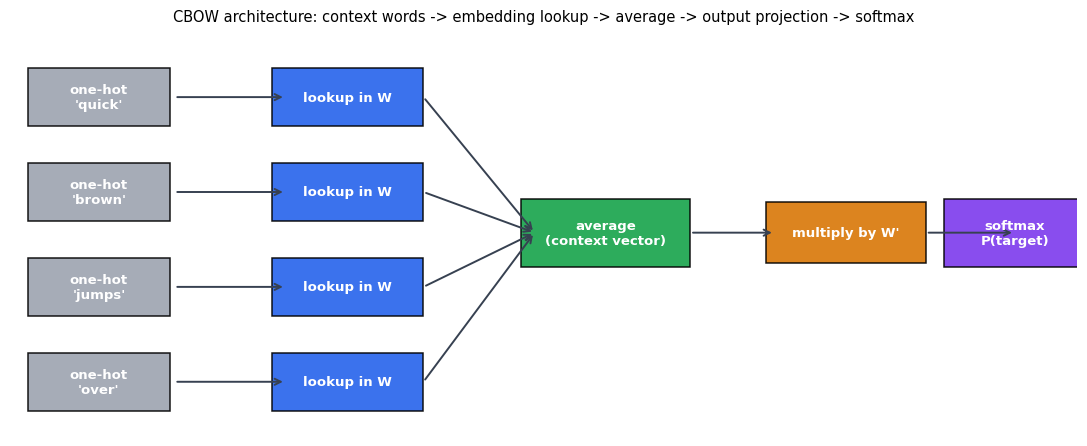

In [3]:
fig, ax = plt.subplots(figsize=(11, 4.6))
ax.axis("off")
ax.set_xlim(0, 12)
ax.set_ylim(0, 6)

box_style = dict(boxstyle="round,pad=0.35", linewidth=1.4)

def box(x, y, text, color, w=1.7, h=0.9, fontsize=9.5):
    ax.add_patch(plt.Rectangle((x - w / 2, y - h / 2), w, h, facecolor=color,
                                 edgecolor="black", alpha=0.9, linewidth=1.1))
    ax.text(x, y, text, ha="center", va="center", fontsize=fontsize, weight="bold", color="white")

def arrow(x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", lw=1.4, color="#374151"))

context_words = ["quick", "brown", "jumps", "over"]
ys = [5, 3.6, 2.2, 0.8]
for w, y in zip(context_words, ys):
    box(1, y, f"one-hot\n'{w}'", "#9ca3af", w=1.6, h=0.85)
    arrow(1.85, y, 3.1, y)
    box(3.8, y, "lookup in W", "#2563eb", w=1.7, h=0.85)
    arrow(4.65, y, 5.9, 3.0)

box(6.7, 3.0, "average\n(context vector)", "#16a34a", w=1.9, h=1.0)
arrow(7.65, 3.0, 8.6, 3.0)
box(9.4, 3.0, "multiply by W'", "#d97706", w=1.8, h=0.9)
arrow(10.3, 3.0, 11.3, 3.0)
box(11.3, 3.0, "softmax\nP(target)", "#7c3aed", w=1.6, h=1.0)

ax.set_title("CBOW architecture: context words -> embedding lookup -> average -> output projection -> softmax",
             fontsize=10.5)
plt.tight_layout()
plt.show()


**Layer-by-layer summary**

- **Input layer.** One-hot vectors of the $2m$ context words, each of size $V$.
- **Embedding (projection) layer.** A shared lookup table $W \in \mathbb{R}^{V\times d}$ — no
  activation function, purely a linear lookup of one row per one-hot vector.
- **Averaging step.** The $2m$ embedding vectors are averaged into one $d$-dimensional context
  vector $\hat v$. This averaging is exactly the "bag" in CBOW — word order is discarded here.
- **Output layer.** $\hat v$ is multiplied by $W' \in \mathbb{R}^{d\times V}$ and passed through
  softmax, producing a probability distribution over all $V$ vocabulary words.
- **Learned embeddings.** After training, the rows of $W$ are the final word vectors used in
  downstream tasks.


## 6. The Softmax Bottleneck and Optimisation Techniques

For each word position $t$ in the corpus, a training pair (context, target) is generated by
sliding a window of size $2m+1$ across the text: the centre word becomes the label, and the $2m$
surrounding words become the input context. For a corpus of $T$ words, this generates
approximately $T \times 2m$ training pairs.

The practical obstacle is the softmax denominator: it requires summing over **every** word in the
vocabulary at **every** training step, making each update $O(V)$. For real vocabularies of
50,000–1,000,000 words, this is far too slow, which motivated two well-known approximations:

| Technique | Complexity | Mechanism | Trade-off |
|---|---|---|---|
| Full softmax | $O(V)$ | Normalise over the entire vocabulary | Exact, but very slow for large $V$ |
| Hierarchical softmax | $O(\log V)$ | Binary Huffman tree; traverse root to leaf | Fast; favours frequent words |
| Negative sampling | $O(k)$, $k\approx 5\text{–}20$ | Binary classification: real pair vs. noise pairs | Very fast; small quality trade-off |

Negative sampling reframes the problem as a set of binary classifications — "is this a true
context pair, or a randomly sampled noise pair?" — and is by far the most widely used technique in
practice (see also the companion notebook on negative sampling for Skip-gram, which uses the same
mechanism).


## 7. From-Scratch Implementation: Training CBOW on a Toy Corpus

To make the mechanics completely concrete, we now build CBOW from scratch with numpy and train it
on a small, deliberately structured corpus. The corpus combines words from four categories
(animals, actions, colours, adjectives) inside repeated sentence templates, so that words from the
same category tend to appear in similar surrounding contexts — exactly the statistical regularity
CBOW is designed to pick up on through the distributional hypothesis.

Because the vocabulary here is tiny (a few dozen words), we use the exact full-softmax objective
rather than an approximation — this keeps the implementation simple while still demonstrating the
complete CBOW mechanism end to end.


In [4]:
rng = np.random.default_rng(7)

animals    = ["dog", "cat", "fox", "wolf", "lion", "tiger"]
actions    = ["runs", "jumps", "walks", "sleeps", "eats", "plays"]
colors     = ["red", "blue", "green", "yellow", "brown", "black"]
adjectives = ["big", "small", "fast", "slow", "happy", "sad"]

category_of = {}
for w in animals:    category_of[w] = "animal"
for w in actions:    category_of[w] = "action"
for w in colors:     category_of[w] = "color"
for w in adjectives: category_of[w] = "adjective"

n_sentences = 600
sentences = []
for _ in range(n_sentences):
    adj = rng.choice(adjectives)
    col = rng.choice(colors)
    ani = rng.choice(animals)
    act = rng.choice(actions)
    sentences.append(["the", adj, col, ani, act, "today"])

vocab = sorted(set(w for s in sentences for w in s))
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}
V = len(vocab)
print(f"Vocabulary size: {V}")
print(vocab)


Vocabulary size: 26
[np.str_('big'), np.str_('black'), np.str_('blue'), np.str_('brown'), np.str_('cat'), np.str_('dog'), np.str_('eats'), np.str_('fast'), np.str_('fox'), np.str_('green'), np.str_('happy'), np.str_('jumps'), np.str_('lion'), np.str_('plays'), np.str_('red'), np.str_('runs'), np.str_('sad'), np.str_('sleeps'), np.str_('slow'), np.str_('small'), 'the', np.str_('tiger'), 'today', np.str_('walks'), np.str_('wolf'), np.str_('yellow')]


In [5]:
def make_cbow_pairs(sentences, window=2):
    pairs = []
    for sent in sentences:
        ids = [word2idx[w] for w in sent]
        for t in range(len(ids)):
            context = []
            for j in range(max(0, t - window), min(len(ids), t + window + 1)):
                if j != t:
                    context.append(ids[j])
            if len(context) > 0:
                pairs.append((context, ids[t]))
    return pairs

pairs = make_cbow_pairs(sentences, window=2)
print(f"Number of (context, target) training pairs: {len(pairs)}")
print("Example pair:", ([idx2word[i] for i in pairs[0][0]], idx2word[pairs[0][1]]))


Number of (context, target) training pairs: 3600
Example pair: ([np.str_('sad'), np.str_('yellow')], 'the')


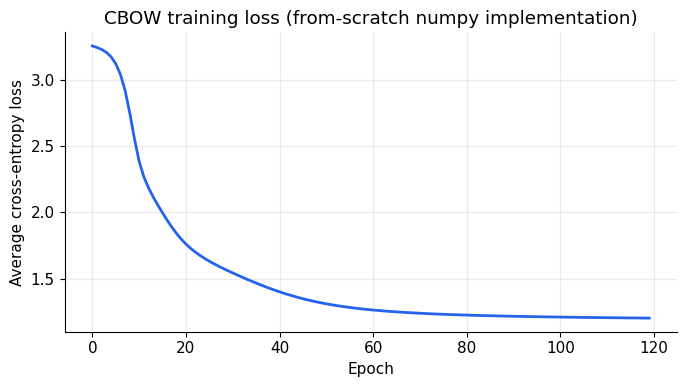

In [6]:
def softmax(x):
    x = x - x.max(axis=1, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=1, keepdims=True)


def train_cbow(pairs, V, d=20, epochs=120, lr=0.08, seed=0):
    rng = np.random.default_rng(seed)
    W = rng.standard_normal((V, d)) * 0.1   # input embeddings
    Wp = rng.standard_normal((d, V)) * 0.1  # output embeddings

    loss_history = []
    n = len(pairs)
    for epoch in range(epochs):
        rng.shuffle(pairs)
        epoch_loss = 0.0
        # mini-batches for speed
        batch_size = 64
        for b in range(0, n, batch_size):
            batch = pairs[b:b + batch_size]
            max_ctx = max(len(c) for c, _ in batch)
            v_hat = np.zeros((len(batch), d))
            targets = np.zeros(len(batch), dtype=int)
            ctx_idx_list = []
            for i, (ctx, tgt) in enumerate(batch):
                ctx_idx_list.append(ctx)
                v_hat[i] = W[ctx].mean(axis=0)
                targets[i] = tgt

            scores = v_hat @ Wp                  # (batch, V)
            probs = softmax(scores)
            batch_loss = -np.log(probs[np.arange(len(batch)), targets] + 1e-9).mean()
            epoch_loss += batch_loss * len(batch)

            # gradient of softmax cross-entropy wrt scores
            dscores = probs.copy()
            dscores[np.arange(len(batch)), targets] -= 1
            dscores /= len(batch)

            dWp = v_hat.T @ dscores              # (d, V)
            dv_hat = dscores @ Wp.T               # (batch, d)

            Wp -= lr * dWp
            for i, ctx in enumerate(ctx_idx_list):
                grad_per_word = dv_hat[i] / len(ctx)
                for c in ctx:
                    W[c] -= lr * grad_per_word

        loss_history.append(epoch_loss / n)
    return W, Wp, loss_history


W, Wp, loss_history = train_cbow(pairs, V, d=20, epochs=120, lr=0.1, seed=1)

plt.figure(figsize=(7, 4))
plt.plot(loss_history, color="#2563eb", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Average cross-entropy loss")
plt.title("CBOW training loss (from-scratch numpy implementation)")
plt.tight_layout()
plt.show()


## 8. Visualising the Learned Embedding Space

After training, the rows of $W$ should encode semantic and syntactic structure even though the
model never received any explicit category labels — it only ever saw raw sentences. We project the
20-dimensional embeddings down to 2 dimensions with PCA and colour each word by its (known, but
never revealed to the model) category. If CBOW has done its job, words from the same category
should cluster together, since they tend to appear in similar surrounding contexts.


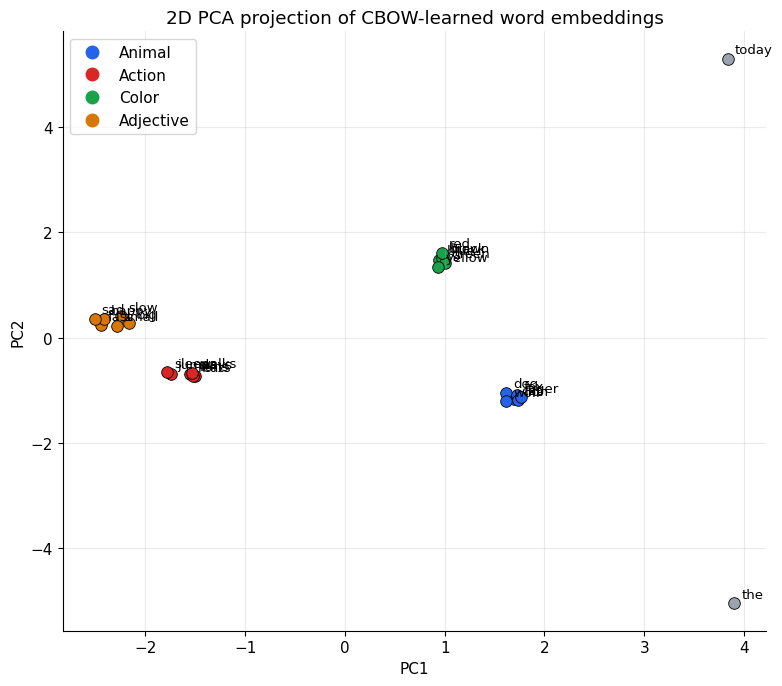

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
emb_2d = pca.fit_transform(W)

color_map = {"animal": "#2563eb", "action": "#dc2626", "color": "#16a34a",
             "adjective": "#d97706", None: "#9ca3af"}

plt.figure(figsize=(8, 7))
for w in vocab:
    cat = category_of.get(w, None)
    xy = emb_2d[word2idx[w]]
    plt.scatter(*xy, color=color_map[cat], s=70, edgecolor="black", linewidth=0.6)
    plt.annotate(w, xy, textcoords="offset points", xytext=(5, 4), fontsize=9.5)

handles = [plt.Line2D([0], [0], marker="o", linestyle="", color=c, label=l, markersize=9)
           for l, c in [("Animal", "#2563eb"), ("Action", "#dc2626"),
                        ("Color", "#16a34a"), ("Adjective", "#d97706")]]
plt.legend(handles=handles, loc="best")
plt.title("2D PCA projection of CBOW-learned word embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


The four categories typically separate into visibly distinct regions of the plot. This is the
distributional hypothesis made tangible: words were grouped purely because of *where* they appear
in sentences relative to other words, with no semantic label ever shown to the model during
training. This is the same qualitative pattern reported in the original CBOW literature, where
semantically related words (e.g. animals, action verbs) cluster together in the learned embedding
space, and consistent vector offsets capture relationships such as plural/singular or verb tense.


## 9. Advantages and Limitations of CBOW

**Advantages**

- **Training speed.** One prediction per centre word (rather than $2m$ separate predictions, as in
  Skip-gram), making CBOW well suited to very large corpora.
- **Frequent-word quality.** Averaging context vectors smooths out noise, producing stable
  representations for common words and syntactic patterns.
- **Memory efficiency.** Only two embedding matrices are required, with a relatively small memory footprint.
- **Noise robustness.** Averaging acts as a mild regulariser — individual noisy context signals are dampened.
- **Simplicity.** A two-layer network with no hidden-layer activation function; easy to implement and tune.

**Limitations**

- **Rare words.** Infrequent words appear in fewer training pairs, so their embeddings are trained
  on less data and tend to be less reliable than in Skip-gram.
- **Loss of word order.** Averaging destroys positional information — "the dog bit the man" and
  "the man bit the dog" can yield the same context vector if the same words are involved.
- **Context dilution.** An informative context word can be averaged out by several less
  informative ones.
- **Static embeddings.** Each word gets exactly one fixed vector regardless of context, so
  polysemous words (e.g. "bank" the river vs. "bank" the institution) share a single vector.
  Contextual models like BERT solve this directly.
- **Linear relationships only.** The embedding space captures linear analogies well but misses
  higher-order semantic structure.


## 10. CBOW vs. Skip-gram

| Aspect | CBOW | Skip-gram |
|---|---|---|
| Objective | Predict target from context words | Predict context words from target |
| Direction | Many-to-one (context → target) | One-to-many (target → context) |
| Training speed | Faster (fewer updates per word) | Slower (more training pairs) |
| Frequent words | Better performance | Slightly worse |
| Rare words | Weaker representations | Stronger representations |
| Semantic analogies | Good | Excellent |
| Memory usage | Lower | Higher |
| Best use case | Large corpora, frequent vocabulary | Small corpora, rare-word quality matters |

**Practical guideline.** Prefer CBOW when training on large corpora where speed matters and
frequent-word quality is the priority; prefer Skip-gram when data is limited or rare-word quality
and analogy performance matter most.


## 11. Applications and Modern Evolution

**Applications.** Text classification (averaged embeddings as document features), semantic
information retrieval, named-entity recognition, machine translation (bilingual embeddings),
transfer learning (pretrained embeddings as initialisation), and recommendation systems
(Item2Vec applies CBOW-style training to user-item interaction sequences).

**What came after CBOW.**

- **GloVe (2014)** combines local context windows with global co-occurrence statistics.
- **FastText (2016)** extends CBOW with subword (character n-gram) information, handling rare
  words and morphologically rich languages far better.
- **ELMo (2018)** produces context-dependent embeddings via a deep bidirectional LSTM — the same
  word gets a different vector in different sentences.
- **BERT (2018)** uses Masked Language Modelling, a direct conceptual descendant of CBOW's
  "predict the missing word from its context" objective, but implemented with a bidirectional
  Transformer encoder with full attention, which solves polysemy entirely.
- **GPT series (2018–2024)** predicts the *next* word autoregressively — directionally closer to
  Skip-gram's spirit, applied at a vastly larger scale.

Despite being surpassed by contextual models, CBOW remains conceptually foundational: it was one
of the earliest demonstrations that meaningful representations can be learned in a fully
self-supervised way from raw, unlabelled text — an idea that underlies essentially all of modern
NLP.


## 12. Conclusion

CBOW efficiently learns distributed word representations by predicting a centre word from the
average of its surrounding context embeddings. Its core strengths are speed, simplicity, and
strong performance on frequent words and syntactic patterns; its core weaknesses are weak
rare-word representations, loss of word order, and static, context-independent vectors. Our
from-scratch implementation showed all of these mechanics directly: averaging context embeddings,
predicting the target with a softmax, and backpropagating through both embedding matrices — and
the resulting 2D projection confirmed that words sharing distributional contexts end up close
together in the learned vector space, exactly as the distributional hypothesis predicts.

**References**

- Mikolov, T., Chen, K., Corrado, G., & Dean, J. (2013). *Efficient Estimation of Word Representations in Vector Space.* arXiv:1301.3781
- Mikolov, T., Sutskever, I., Chen, K., Corrado, G., & Dean, J. (2013). *Distributed Representations of Words and Phrases and their Compositionality.* arXiv:1310.4546
- Firth, J. R. (1957). *A Synopsis of Linguistic Theory 1930–1955.*
- Pennington, J., Socher, R., & Manning, C. (2014). *GloVe: Global Vectors for Word Representation.* EMNLP 2014
- Bojanowski, P., Grave, E., Joulin, A., & Mikolov, T. (2017). *Enriching Word Vectors with Subword Information.* TACL
- Devlin, J., Chang, M. W., Lee, K., & Toutanova, K. (2018). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding.* arXiv:1810.04805
